<a href="https://colab.research.google.com/github/dioufabdoulaye910/tb-detection-deep-learning/blob/main/03_CNN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 3 : Modélisation CNN - Détection de la Tuberculose

Dans cette phase, nous construisons un modèle de réseau de neurones convolutifs (CNN) pour classifier les radiographies pulmonaires en deux classes :
- Normal
- Tuberculose

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

import matplotlib.pyplot as plt
import numpy as np

In [10]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
data_path = "/content/drive/MyDrive/TB_Chest_Radiography_Database"

tb_path = os.path.join(data_path, "Tuberculosis")
normal_path = os.path.join(data_path, "Normal")

In [13]:
IMG_SIZE = 224

def load_images(folder, label):
    data = []
    for img_name in os.listdir(folder):
        try:
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            data.append([img, label])
        except:
            pass
    return data

In [14]:
tb_data = load_images(tb_path, 1)
normal_data = load_images(normal_path, 0)

dataset = tb_data + normal_data

In [15]:
import random
random.shuffle(dataset)

X = np.array([i[0] for i in dataset], dtype="float32") / 255.0
y = np.array([i[1] for i in dataset])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3360, 224, 224, 3)
(840, 224, 224, 3)
(3360,)
(840,)


In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [18]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

In [19]:
model = Sequential([
    data_augmentation,

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [21]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    class_weight={0:0.6, 1:3.0}
)

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 402s 4s/step - accuracy: 0.5634 - loss: 0.7085 - val_accuracy: 0.9226 - val_loss: 0.3390
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 452s 4s/step - accuracy: 0.8411 - loss: 0.4246 - val_accuracy: 0.9119 - val_loss: 0.2285
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 441s 4s/step - accuracy: 0.8443 - loss: 0.3906 - val_accuracy: 0.9369 - val_loss: 0.2566
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 409s 4s/step - accuracy: 0.8920 - loss: 0.3053 - val_accuracy: 0.9429 - val_loss: 0.1726
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 391s 4s/step - accuracy: 0.9119 - loss: 0.2773 - val_accuracy: 0.9536 - val_loss: 0.1767
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 441s 4s/step - accuracy: 0.9083 - loss: 0.2566 - val_accuracy: 0.9607 - val_loss: 0.1334
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 457s 4s/step - accuracy: 0.9065 - loss: 0.2531 - val_accuracy: 0.9571 - val_loss: 0.1212
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 408s 4s/step - accuracy: 0.9223 - loss: 0.2205 - val_accu

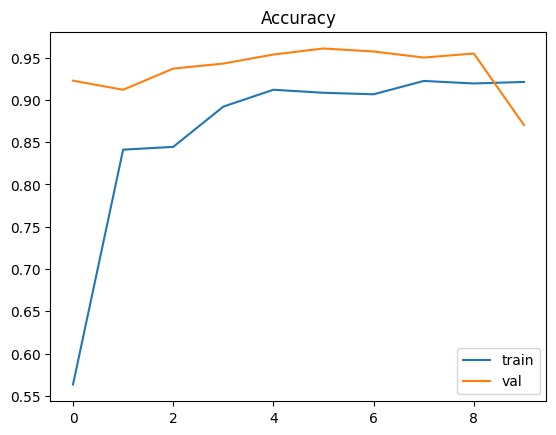

In [26]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

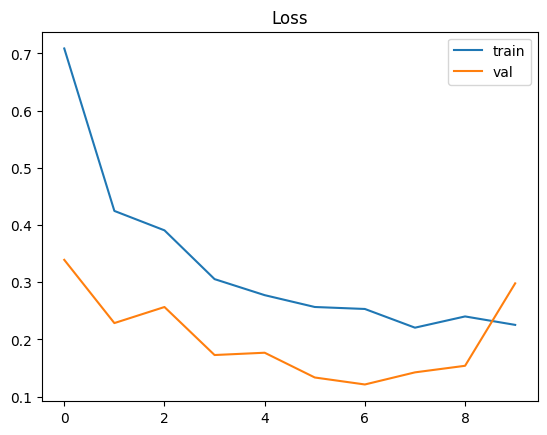

In [27]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

In [28]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

27/27 ━━━━━━━━━━━━━━━━━━━━ 25s 918ms/step - accuracy: 0.8702 - loss: 0.2980
Test Accuracy: 0.8702380657196045


In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print(classification_report(y_test, y_pred))

27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 834ms/step
              precision    recall  f1-score   support

           0       0.97      0.87      0.92       700
           1       0.57      0.89      0.69       140

    accuracy                           0.87       840
   macro avg       0.77      0.88      0.81       840
weighted avg       0.91      0.87      0.88       840



In [30]:
model.save("tb_detection_cnn.h5")

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [3]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [4]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [5]:
model = models.Sequential([
    data_augmentation,

    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.4),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')
])

In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [22]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    class_weight={0:0.6, 1:3.0}
)

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 418s 4s/step - accuracy: 0.7345 - loss: 0.5562 - val_accuracy: 0.9119 - val_loss: 0.2143
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 415s 4s/step - accuracy: 0.8622 - loss: 0.3854 - val_accuracy: 0.7893 - val_loss: 0.4085
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 437s 4s/step - accuracy: 0.9119 - loss: 0.2648 - val_accuracy: 0.9333 - val_loss: 0.1840
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 411s 4s/step - accuracy: 0.9122 - loss: 0.2399 - val_accuracy: 0.9262 - val_loss: 0.1987
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 411s 4s/step - accuracy: 0.9137 - loss: 0.2160 - val_accuracy: 0.9464 - val_loss: 0.1299
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 424s 4s/step - accuracy: 0.9265 - loss: 0.2083 - val_accuracy: 0.9631 - val_loss: 0.1296
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 413s 4s/step - accuracy: 0.9336 - loss: 0.1886 - val_accuracy: 0.9274 - val_loss: 0.1809
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 412s 4s/step - accuracy: 0.9068 - loss: 0.2603 - val_accu

In [23]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

27/27 ━━━━━━━━━━━━━━━━━━━━ 25s 920ms/step - accuracy: 0.9417 - loss: 0.2018
Test Accuracy: 0.9416666626930237


In [24]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print(classification_report(y_test, y_pred))

27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 854ms/step
              precision    recall  f1-score   support

           0       0.99      0.94      0.96       700
           1       0.76      0.96      0.85       140

    accuracy                           0.94       840
   macro avg       0.87      0.95      0.90       840
weighted avg       0.95      0.94      0.94       840



27/27 ━━━━━━━━━━━━━━━━━━━━ 27s 934ms/step


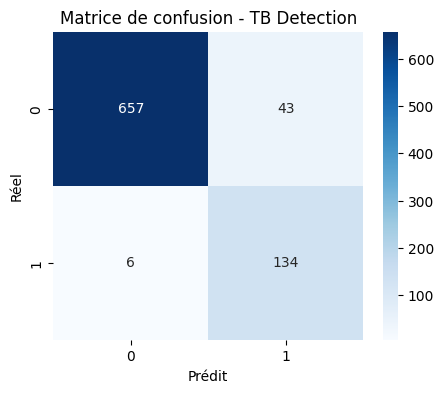

In [25]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion - TB Detection")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

27/27 ━━━━━━━━━━━━━━━━━━━━ 26s 960ms/step


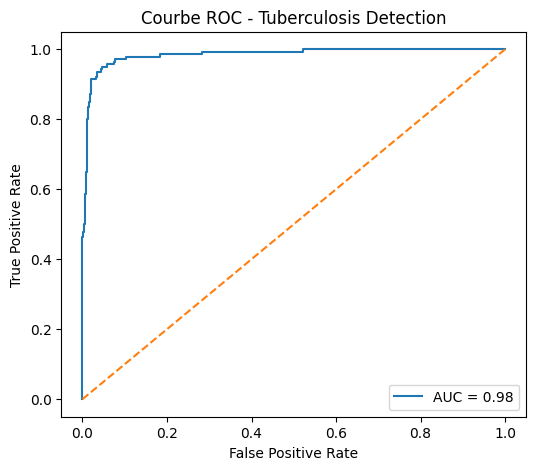

In [26]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict(X_test).ravel()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC - Tuberculosis Detection")
plt.legend()
plt.show()

In [27]:
model.save("tb_mobilenetv2_model.h5")

In [28]:
from google.colab import drive
drive.mount('/content/drive')

model.save("/content/drive/MyDrive/tb_mobilenetv2_model.h5")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Conclusion de la Phase de Modélisation

Dans cette phase, nous avons développé et entraîné un modèle de Deep Learning pour la détection automatique de la tuberculose à partir de radiographies pulmonaires.

Deux approches ont été testées :
- Un modèle CNN classique
- Un modèle basé sur le transfer learning avec MobileNetV2

Le modèle CNN a atteint une accuracy de 87%, tandis que le modèle MobileNetV2 a significativement amélioré les performances avec une accuracy de 94%.

Les résultats montrent que le transfer learning permet une meilleure généralisation et une meilleure détection des cas de tuberculose, ce qui est essentiel dans un contexte médical où le rappel (recall) est une métrique critique.

Le modèle final est capable de distinguer efficacement les cas normaux et les cas de tuberculose, avec une bonne performance globale et un faible taux d’erreurs critiques.

Cette phase valide la faisabilité d’un système automatique d’aide au diagnostic basé sur l’intelligence artificielle.